## 1: Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier 
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix ,ConfusionMatrixDisplay ,accuracy_score ,recall_score ,precision_score ,f1_score)

## 2: Loading Dataset

In [2]:
# Loading dataset,
# Data quick Check.
df = pd.read_csv('Car Insurance prediction Domain-BFSI (1).csv')

In [3]:
df.head()

,policy_id,policy_tenure,age_of_car,age_of_policyholder,area_cluster,population_density,make,segment,model,fuel_type,...,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,is_claim
0,ID00001,0.515874,0.05,0.644231,C1,4990,1,A,M1,CNG,...,No,No,No,Yes,No,No,No,Yes,0,0
1,ID00002,0.672619,0.02,0.375000,C2,27003,1,A,M1,CNG,...,No,No,No,Yes,No,No,No,Yes,0,0
2,ID00003,0.841110,0.02,0.384615,C3,4076,1,A,M1,CNG,...,No,No,No,Yes,No,No,No,Yes,0,0
3,ID00004,0.900277,0.11,0.432692,C4,21622,1,C1,M2,Petrol,...,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,2,0
4,ID00005,0.596403,0.11,0.634615,C5,34738,2,A,M3,Petrol,...,No,Yes,Yes,Yes,No,Yes,Yes,Yes,2,0


In [4]:
#Checking shape of the dataset
df.shape

(58592, 44)

In [5]:
# Checking the size of dataset
df.size

2578048

In [6]:
# Checking column names of dataset
df.columns

Index(['policy_id', 'policy_tenure', 'age_of_car', 'age_of_policyholder',
       'area_cluster', 'population_density', 'make', 'segment', 'model',
       'fuel_type', 'max_torque', 'max_power', 'engine_type', 'airbags',
       'is_esc', 'is_adjustable_steering', 'is_tpms', 'is_parking_sensors',
       'is_parking_camera', 'rear_brakes_type', 'displacement', 'cylinder',
       'transmission_type', 'gear_box', 'steering_type', 'turning_radius',
       'length', 'width', 'height', 'gross_weight', 'is_front_fog_lights',
       'is_rear_window_wiper', 'is_rear_window_washer',
       'is_rear_window_defogger', 'is_brake_assist', 'is_power_door_locks',
       'is_central_locking', 'is_power_steering',
       'is_driver_seat_height_adjustable', 'is_day_night_rear_view_mirror',
       'is_ecw', 'is_speed_alert', 'ncap_rating', 'is_claim'],
      dtype='object')

In [7]:
# Checking the Data-Types of the columns
df.dtypes

policy_id                            object
policy_tenure                       float64
age_of_car                          float64
age_of_policyholder                 float64
area_cluster                         object
population_density                    int64
make                                  int64
segment                              object
model                                object
fuel_type                            object
max_torque                           object
max_power                            object
engine_type                          object
airbags                               int64
is_esc                               object
is_adjustable_steering               object
is_tpms                              object
is_parking_sensors                   object
is_parking_camera                    object
rear_brakes_type                     object
displacement                          int64
cylinder                              int64
transmission_type               

In [8]:
#Checking the information of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58592 entries, 0 to 58591
Data columns (total 44 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   policy_id                         58592 non-null  object 
 1   policy_tenure                     58592 non-null  float64
 2   age_of_car                        58592 non-null  float64
 3   age_of_policyholder               58592 non-null  float64
 4   area_cluster                      58592 non-null  object 
 5   population_density                58592 non-null  int64  
 6   make                              58592 non-null  int64  
 7   segment                           58592 non-null  object 
 8   model                             58592 non-null  object 
 9   fuel_type                         58592 non-null  object 
 10  max_torque                        58592 non-null  object 
 11  max_power                         58592 non-null  object 
 12  engi

In [9]:
# is_claim Is the Target column
# Checking the value counts for number of unique values
df['is_claim'].value_counts()

is_claim
0    54844
1     3748
Name: count, dtype: int64

In [10]:
# Checking the percentage of number of unique values are present
df['is_claim'].value_counts(normalize=True)*100

is_claim
0    93.603222
1     6.396778
Name: proportion, dtype: float64

#### Note 1: Target column is imballance

## 3 Checking missing & duplicate data

In [11]:
df.isnull().sum() # Zero Null values

policy_id                           0
policy_tenure                       0
age_of_car                          0
age_of_policyholder                 0
area_cluster                        0
population_density                  0
make                                0
segment                             0
model                               0
fuel_type                           0
max_torque                          0
max_power                           0
engine_type                         0
airbags                             0
is_esc                              0
is_adjustable_steering              0
is_tpms                             0
is_parking_sensors                  0
is_parking_camera                   0
rear_brakes_type                    0
displacement                        0
cylinder                            0
transmission_type                   0
gear_box                            0
steering_type                       0
turning_radius                      0
length      

In [12]:
#Checking duplicated values
df.duplicated().sum() #-- Zero duplicated values

0

##### Note 2: zero missing values
##### Note 3: zero duplicate values

## 4 Sorting Categorical and Numerical Columns in list

In [13]:
categorical=[]
numerical=[]

#### seperating categorical columns

In [14]:
for i in df.select_dtypes(include='object').columns:
    print(i,":",df[i].nunique())
    categorical.append(i)
print("\n\n")
print(categorical)

policy_id : 58592
area_cluster : 22
segment : 6
model : 11
fuel_type : 3
max_torque : 9
max_power : 9
engine_type : 11
is_esc : 2
is_adjustable_steering : 2
is_tpms : 2
is_parking_sensors : 2
is_parking_camera : 2
rear_brakes_type : 2
transmission_type : 2
steering_type : 3
is_front_fog_lights : 2
is_rear_window_wiper : 2
is_rear_window_washer : 2
is_rear_window_defogger : 2
is_brake_assist : 2
is_power_door_locks : 2
is_central_locking : 2
is_power_steering : 2
is_driver_seat_height_adjustable : 2
is_day_night_rear_view_mirror : 2
is_ecw : 2
is_speed_alert : 2



['policy_id', 'area_cluster', 'segment', 'model', 'fuel_type', 'max_torque', 'max_power', 'engine_type', 'is_esc', 'is_adjustable_steering', 'is_tpms', 'is_parking_sensors', 'is_parking_camera', 'rear_brakes_type', 'transmission_type', 'steering_type', 'is_front_fog_lights', 'is_rear_window_wiper', 'is_rear_window_washer', 'is_rear_window_defogger', 'is_brake_assist', 'is_power_door_locks', 'is_central_locking', 'is_power_ste

#### columns which are numerical in nature but they are categorical (as its unique values are very less)

In [15]:
# Aproximatly 60K rows and unique values which are less than 25 we are considerning as categorical.

for i in df.select_dtypes(include=['int64','float64']).columns:
    print(i,":",df[i].nunique())
    if df[i].nunique()>25:
        numerical.append(i)
    else:
        categorical.append(i)
print("\n\n")
print(numerical)

policy_tenure : 58592
age_of_car : 49
age_of_policyholder : 75
population_density : 22
make : 5
airbags : 3
displacement : 9
cylinder : 2
gear_box : 2
turning_radius : 9
length : 9
width : 10
height : 11
gross_weight : 10
ncap_rating : 5
is_claim : 2



['policy_tenure', 'age_of_car', 'age_of_policyholder']


# 5 Exploratory Data Analysis(EDA)

### A] Categorical EDA

#### Pie Chart

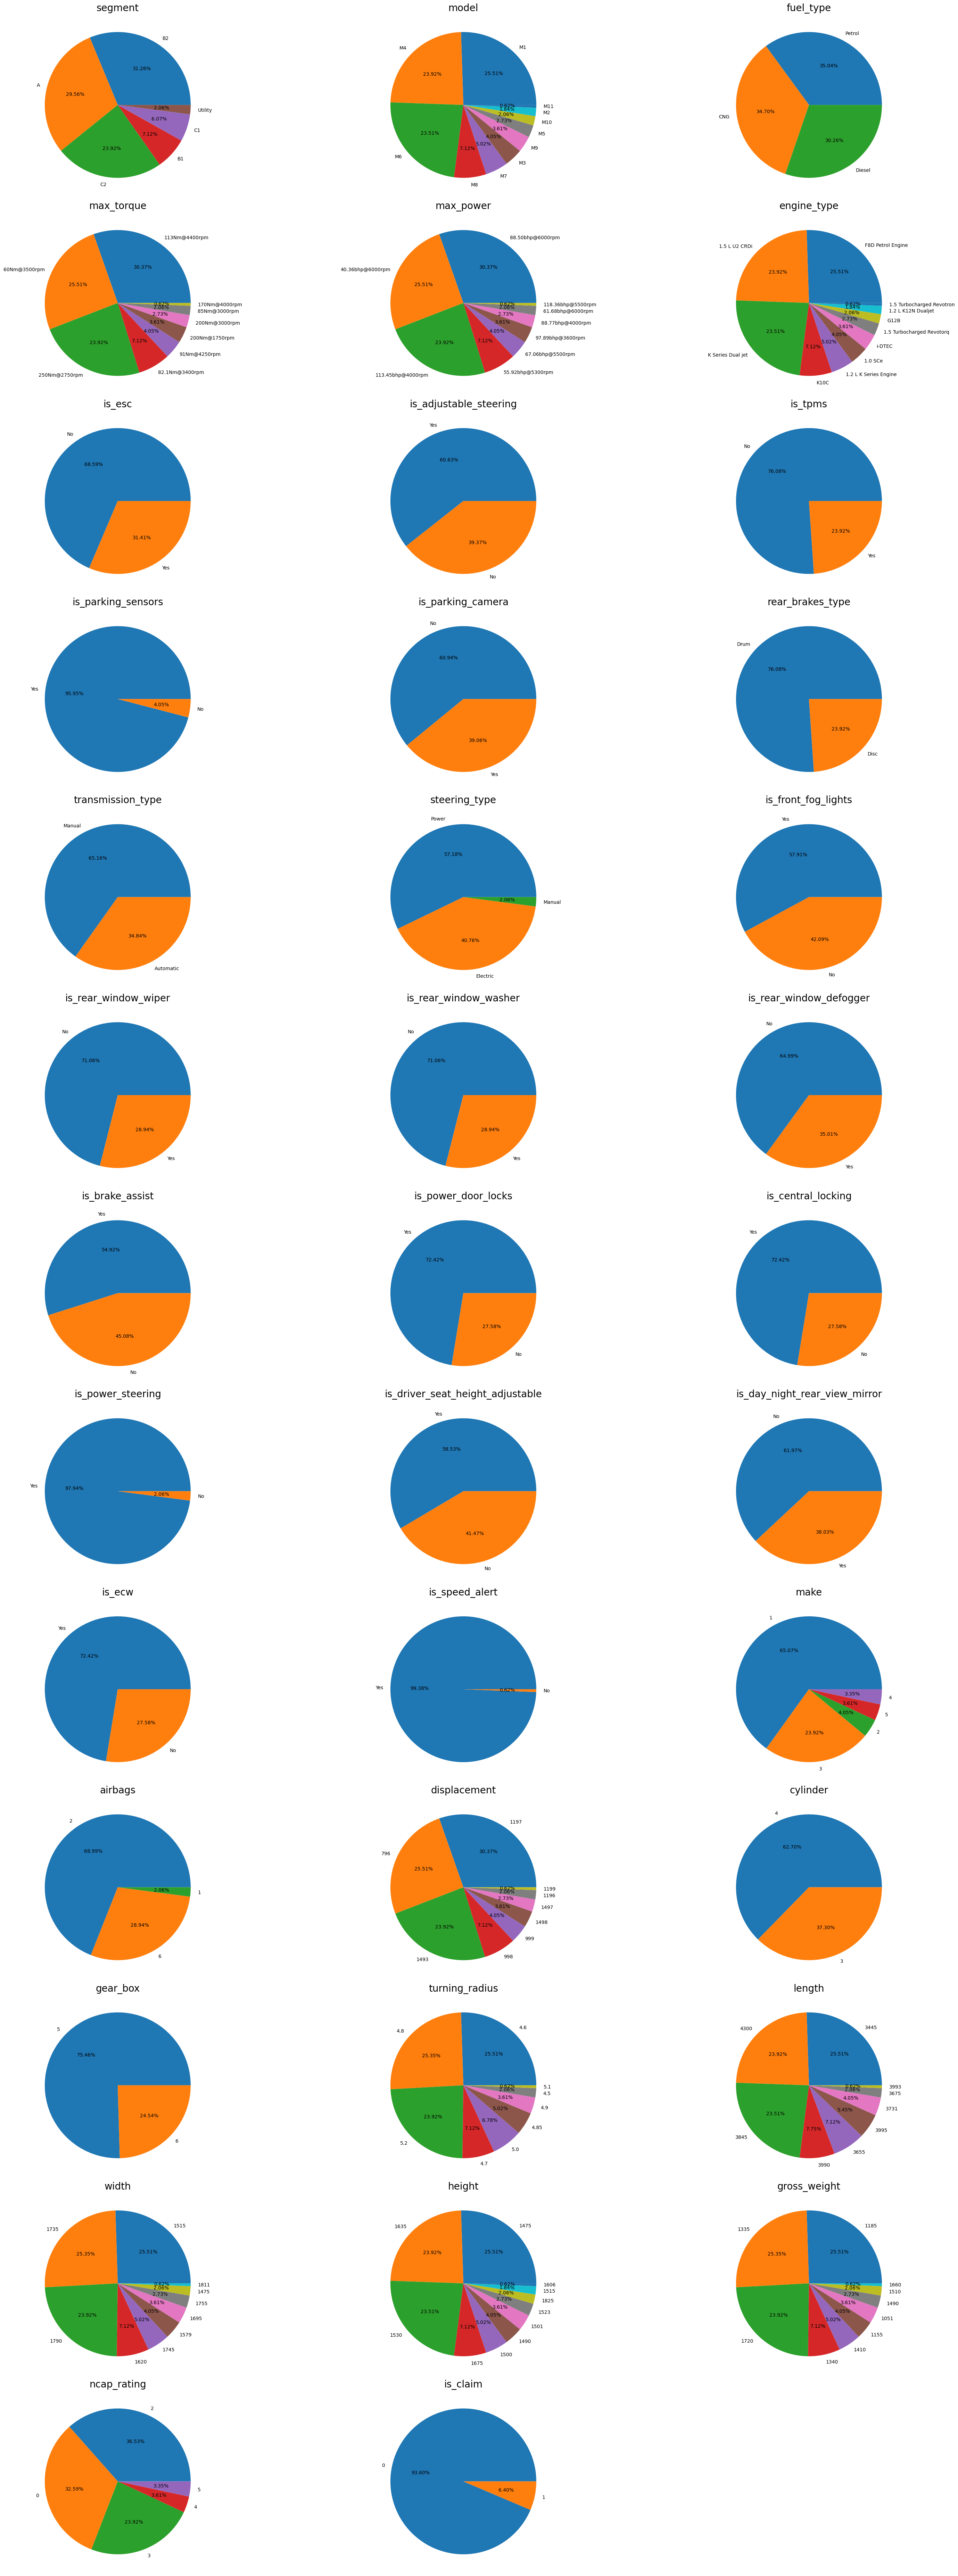

In [16]:
# # Only 2 features are above 11 for categorical..
# # only 2 features are == 11 rest are below 11 for cat...
# # Only 1 feature is having 22 for that bar chart preffer..
fig=plt.figure(figsize=(30,80))
count=1
for i in categorical:
     if df[i].nunique() < 15:
         keys=df[i].value_counts().keys()
         values=df[i].value_counts().values
         plt.subplot(14,3,count)
         plt.pie(x=values, labels=keys, autopct='%0.2f%%')
         plt.title(i, fontsize=20)
         fig.tight_layout()
         count+=1
plt.show()        

#### Countplot

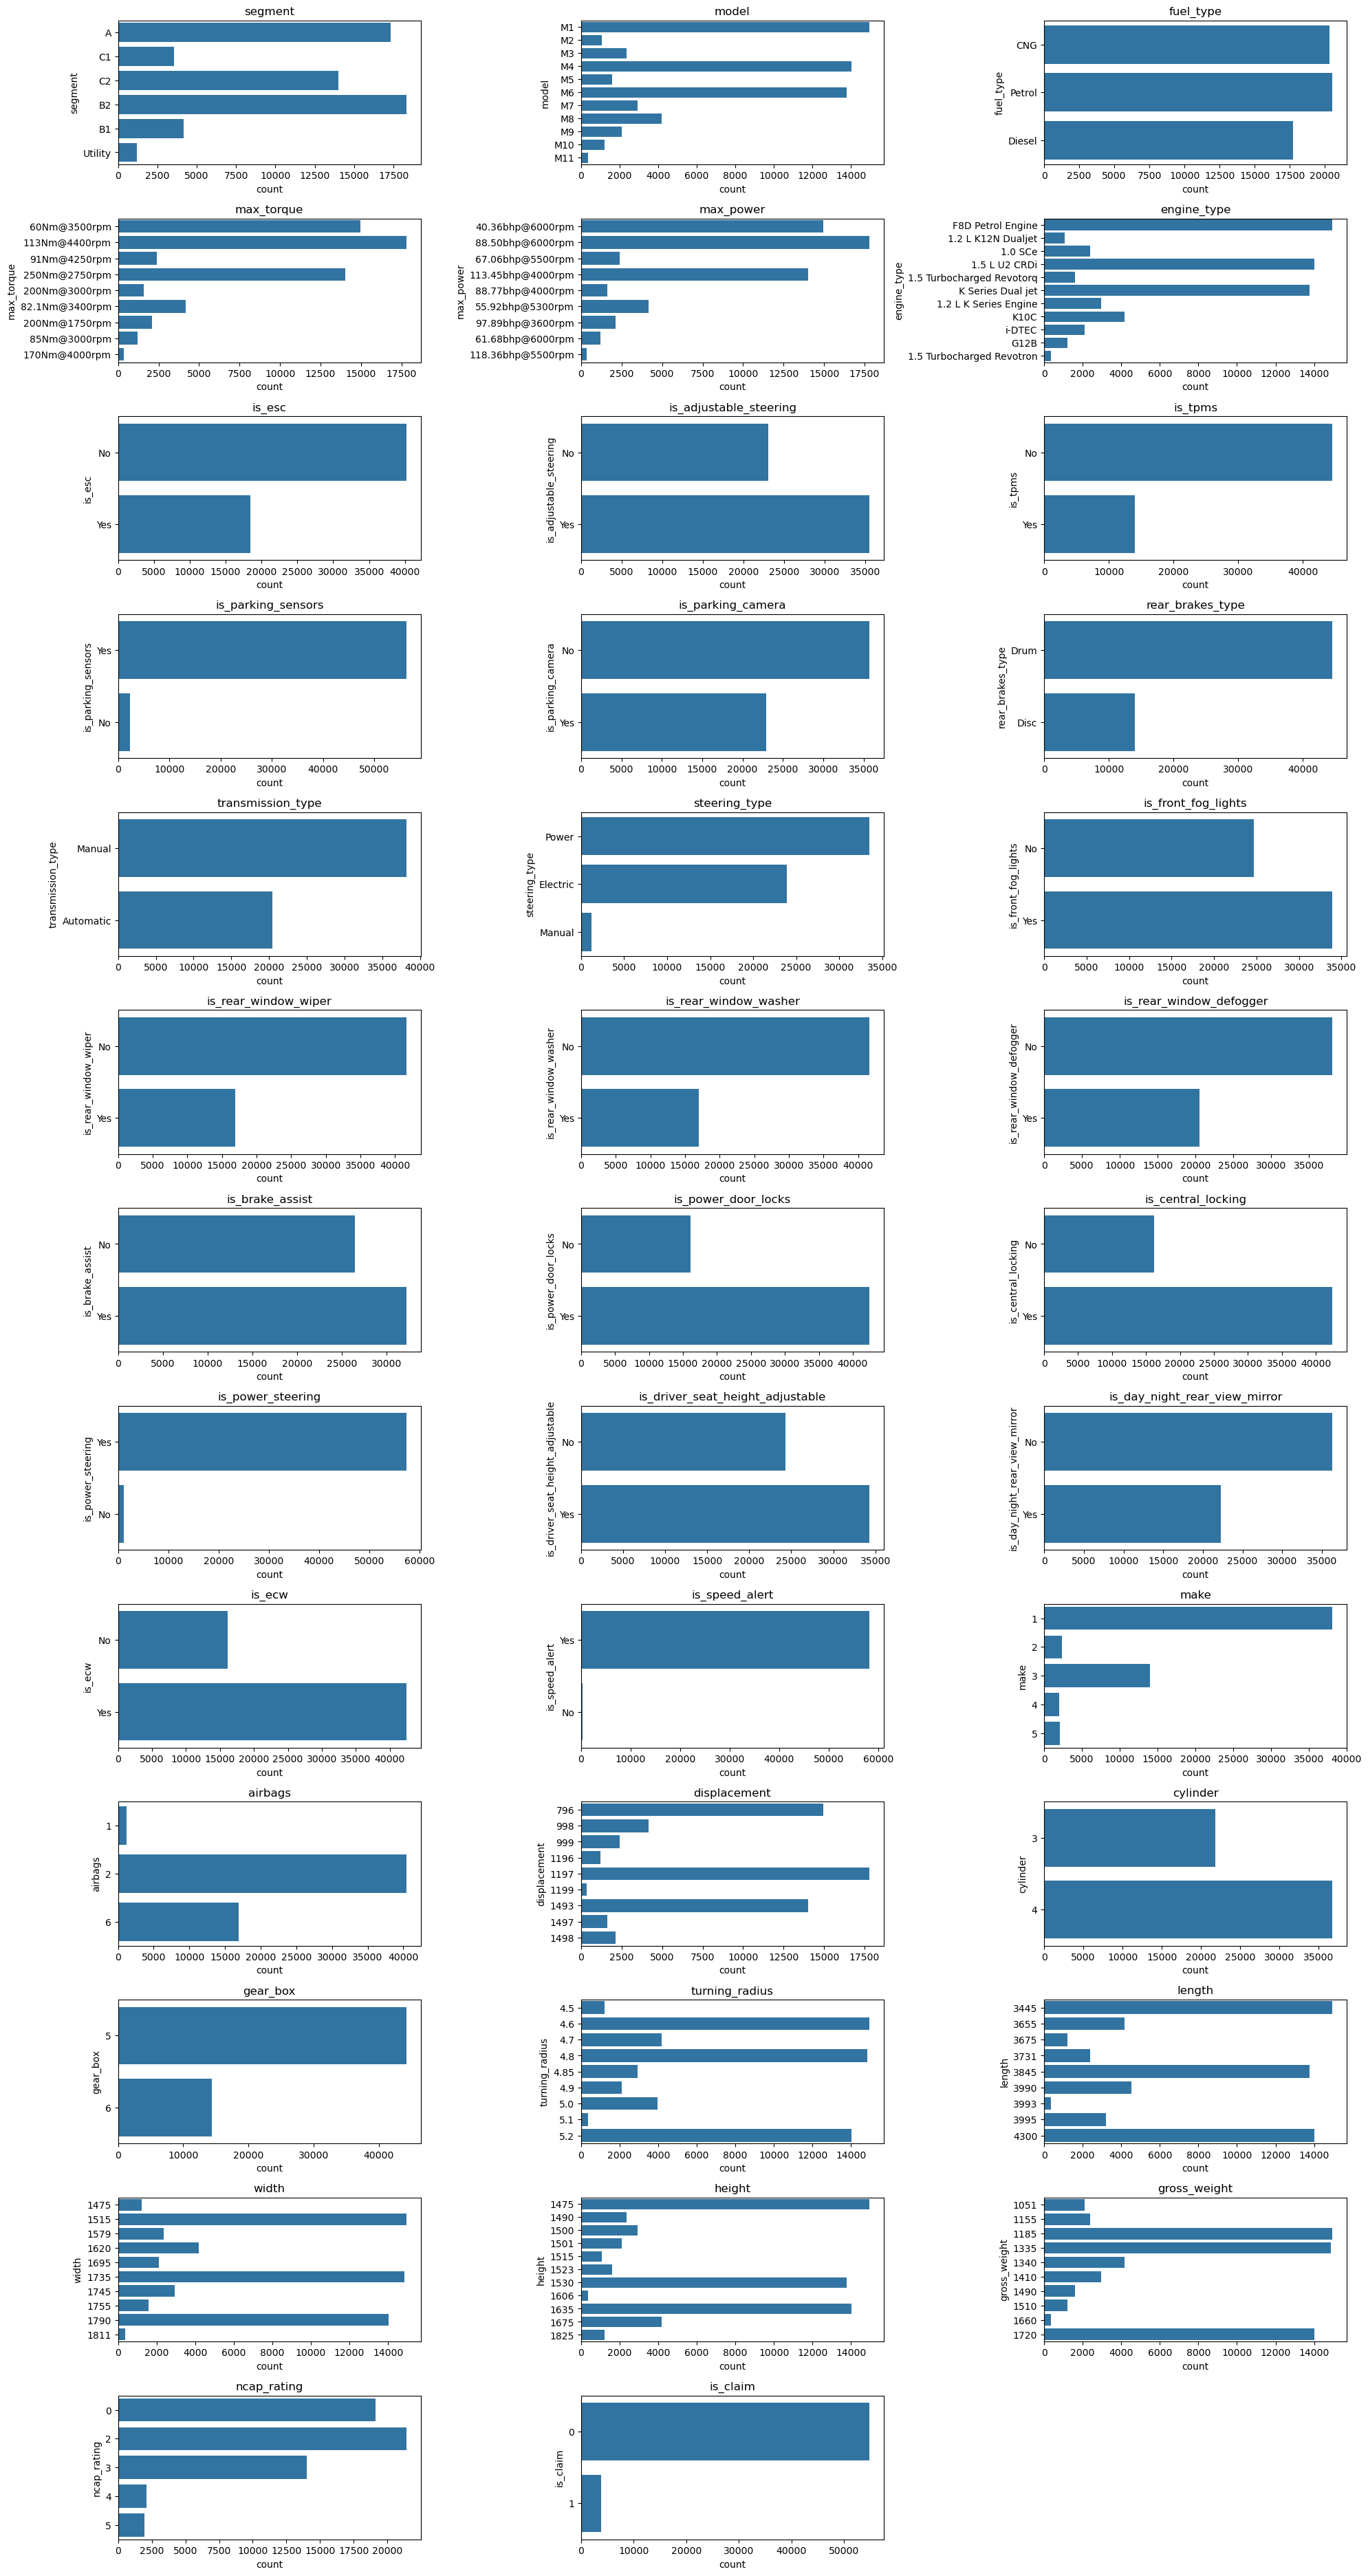

In [17]:
# Example countplot for a single categorical variable
count=1
fig=plt.figure(figsize=(20,40))
for i in categorical:
     if df[i].nunique() <= 11:
        plt.subplot(14,3,count)
        sns.countplot(y=i, data=df)
        plt.title(i) 
        plt.xlabel('count')
        plt.ylabel(i)
        fig.tight_layout() #
        count+=1 
plt.show()

In [18]:
# Counting no.of unique values in every catogarical columns 
df[categorical].nunique()

policy_id                           58592
area_cluster                           22
segment                                 6
model                                  11
fuel_type                               3
max_torque                              9
max_power                               9
engine_type                            11
is_esc                                  2
is_adjustable_steering                  2
is_tpms                                 2
is_parking_sensors                      2
is_parking_camera                       2
rear_brakes_type                        2
transmission_type                       2
steering_type                           3
is_front_fog_lights                     2
is_rear_window_wiper                    2
is_rear_window_washer                   2
is_rear_window_defogger                 2
is_brake_assist                         2
is_power_door_locks                     2
is_central_locking                      2
is_power_steering                 

In [19]:
# checking unique values of categorical columns which are less than 25
for i in categorical:
    if df[i].nunique()<25:
        print(i,df[i].unique(),end="\n\n")

area_cluster ['C1' 'C2' 'C3' 'C4' 'C5' 'C6' 'C7' 'C8' 'C9' 'C10' 'C11' 'C12' 'C13'
 'C14' 'C15' 'C16' 'C17' 'C18' 'C19' 'C20' 'C21' 'C22']

segment ['A' 'C1' 'C2' 'B2' 'B1' 'Utility']

model ['M1' 'M2' 'M3' 'M4' 'M5' 'M6' 'M7' 'M8' 'M9' 'M10' 'M11']

fuel_type ['CNG' 'Petrol' 'Diesel']

max_torque ['60Nm@3500rpm' '113Nm@4400rpm' '91Nm@4250rpm' '250Nm@2750rpm'
 '200Nm@3000rpm' '82.1Nm@3400rpm' '200Nm@1750rpm' '85Nm@3000rpm'
 '170Nm@4000rpm']

max_power ['40.36bhp@6000rpm' '88.50bhp@6000rpm' '67.06bhp@5500rpm'
 '113.45bhp@4000rpm' '88.77bhp@4000rpm' '55.92bhp@5300rpm'
 '97.89bhp@3600rpm' '61.68bhp@6000rpm' '118.36bhp@5500rpm']

engine_type ['F8D Petrol Engine' '1.2 L K12N Dualjet' '1.0 SCe' '1.5 L U2 CRDi'
 '1.5 Turbocharged Revotorq' 'K Series Dual jet' '1.2 L K Series Engine'
 'K10C' 'i-DTEC' 'G12B' '1.5 Turbocharged Revotron']

is_esc ['No' 'Yes']

is_adjustable_steering ['No' 'Yes']

is_tpms ['No' 'Yes']

is_parking_sensors ['Yes' 'No']

is_parking_camera ['No' 'Yes']

rear_brakes_ty

In [20]:
# fig=plt.figure(figsize=(10,10))
# count=1
# for i in categorical:
#      if df[i].nunique() <= 11:
#          keys=df[i].value_counts().keys()
#          values=df[i].value_counts().values
#          plt.figure(figsize = (10,10))
#          plt.bar(keys, values)
#          plt.title(i)
#          plt.xlabel('count')
#          plt.ylabel(i)
#          plt.bar(keys, values, color=['Red','blue','green'])   
# plt.show()

#### Count plot with hue of target column(target_col= 'is_claim')

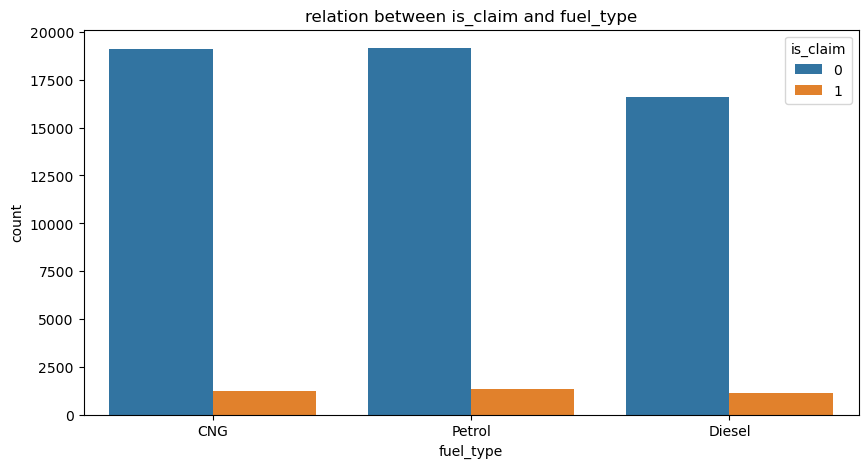

In [21]:
# Count plot with hue of target column
plt.figure(figsize=(10,5))
sns.countplot(data = df ,x= "fuel_type" , hue ="is_claim")
plt.title("relation between is_claim and fuel_type")
plt.show()

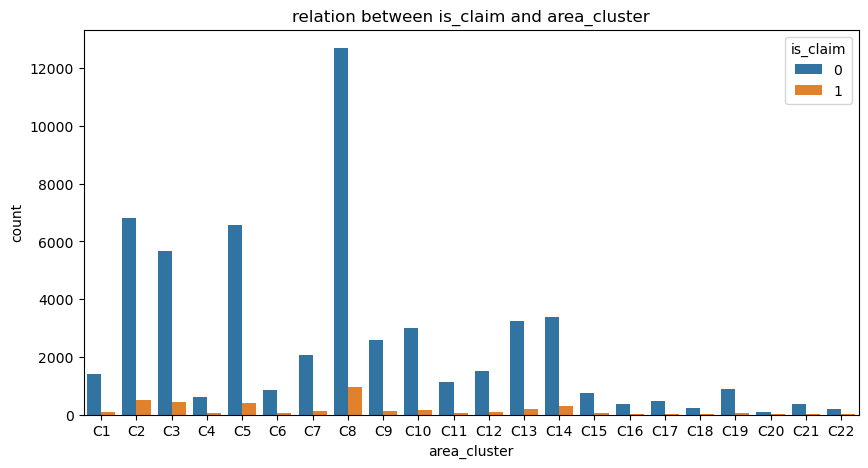

In [22]:
# Count plot with hue of target column
plt.figure(figsize=(10,5))
sns.countplot(data = df ,x= "area_cluster" , hue ="is_claim")
plt.title("relation between is_claim and area_cluster")
plt.show()

<Figure size 4000x4000 with 0 Axes>

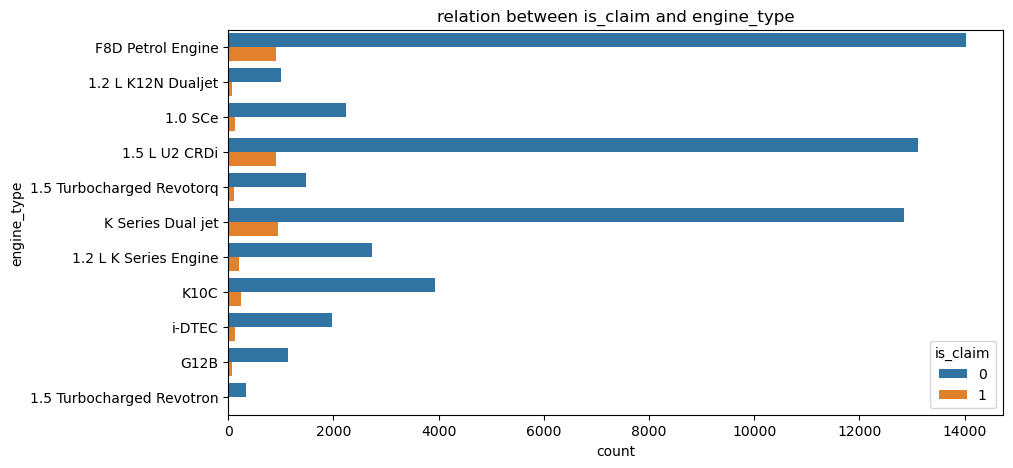

In [23]:
# Count plot with hue of target column
fig=plt.figure(figsize=(40,40))
plt.figure(figsize=(10,5))
sns.countplot(data = df, y= "engine_type", hue ="is_claim")
plt.title("relation between is_claim and engine_type")
plt.show()

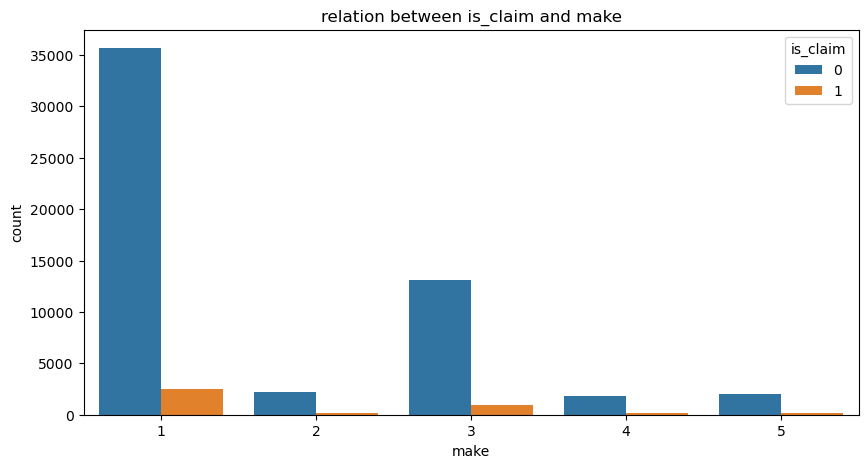

In [24]:
plt.figure(figsize=(10,5))
sns.countplot(data = df ,x= "make" , hue ="is_claim")
plt.title("relation between is_claim and make")
plt.show()

In [25]:
# pip install seaborn --upgrade ----> upgraded seaborn because 'hue' was not working 

##### Note7: (no. of rows in df = no. of unique values in policy_id. Need to check wheather to keep or drop (policy_id))

### Numerical EDA

#### Distplot

In [26]:
# # Distplot is no longer supported in updated seaborn
# for i in numerical:
#  sns.distplot(df[i], bins=10)
#  plt.show()

#### Boxplot

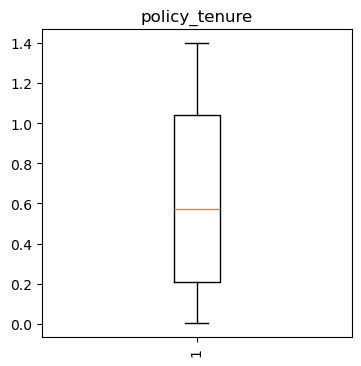

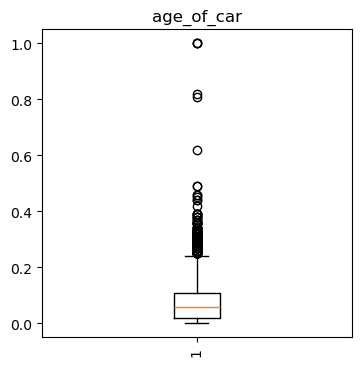

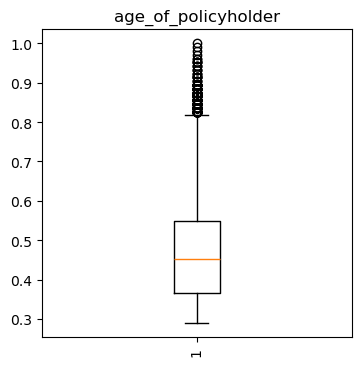

In [27]:
# whole numerical col. visulizing in boxplot
for i in numerical:
   # if df[i].nunique()<1000:
        
       plt.figure(figsize=(4,4))
       plt.title(i) 
       plt.boxplot(x=i, data=df)
       plt.xticks(rotation=90)
plt.show()

#### NOTE 8: age_of_car & age_of_policyholder has many outliers population_density has less outliers

#### Five points summary of numerical columns

In [28]:
df[numerical].describe()

,policy_tenure,age_of_car,age_of_policyholder
count,58592.000000,58592.000000,58592.000000
mean,0.611246,0.069424,0.469420
std,0.414156,0.056721,0.122886
min,0.002735,0.000000,0.288462
25%,0.210250,0.020000,0.365385
50%,0.573792,0.060000,0.451923
75%,1.039104,0.110000,0.548077
max,1.396641,1.000000,1.000000


#### Histogram

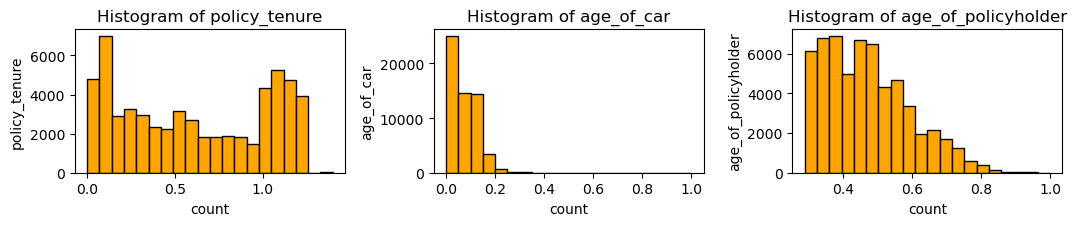

In [29]:
plt.figure(figsize=(18, 10))
for idx, i in enumerate(numerical):
    plt.subplot(5, 5, idx + 1)  # Adjust grid size (5x5) based on number of numerical columns
    plt.hist(df[i], bins=20, color='orange', edgecolor='black')
    plt.title(f'Histogram of {i}')
    plt.xlabel('count')
    plt.ylabel(i)
plt.tight_layout()
plt.show()

#### KDEplot

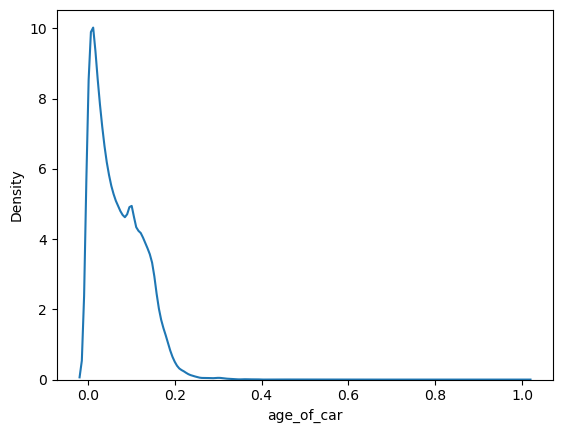

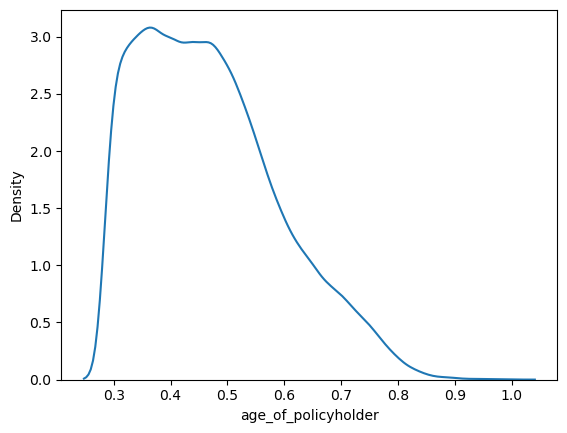

In [30]:
for i in numerical:
    if df[i].nunique() < 1000:
        sns.kdeplot(data=df[i])
        plt.show()    

#### Correlation matrix of numerical column

In [31]:
df[numerical].corr()

,policy_tenure,age_of_car,age_of_policyholder
policy_tenure,1.000000,0.166312,0.143676
age_of_car,0.166312,1.000000,-0.035427
age_of_policyholder,0.143676,-0.035427,1.000000


#### multicolinearity is very less

#### Heatmap of numerical columns

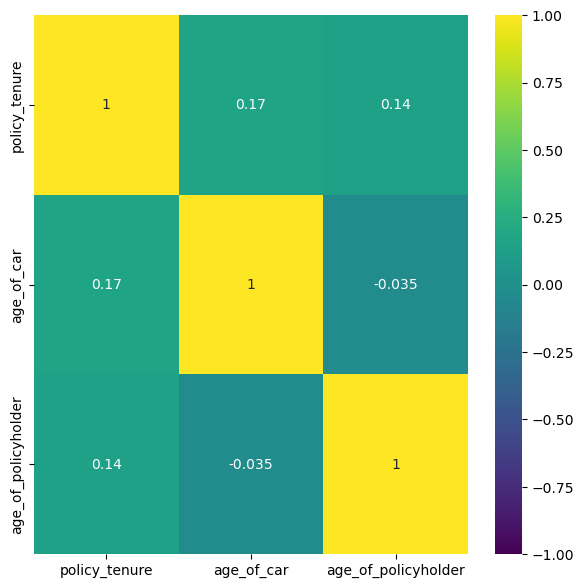

In [32]:
plt.figure(figsize=(7,7))
sns.heatmap(data=df[numerical].corr(),cmap='viridis',vmin=-1,vmax=1,annot=True)
plt.show()

## 6 Outlier Analysis

In [33]:
numerical

['policy_tenure', 'age_of_car', 'age_of_policyholder']

In [34]:
#### IQR Method To Handle Outlier

In [35]:
# Creating Upper limit & lower limit

for i in ['age_of_car','age_of_policyholder']:
    q1 = np.percentile(df[i], 25)
    q3 = np.percentile(df[i], 75)
    IQR=q3 - q1
    ul=q3+1.5*IQR
    ll=q1-1.5*IQR
    print(f"{i}:\nq1={q1},q3={q3},IQR={IQR}")
    print("upper limit",ul,"lower limit",ll)
    print("")
    df[i]=np.where(df[i]>ul,ul,df[i])
    df[i]=np.where(df[i]<ll,ll,df[i])


age_of_car:
q1=0.02,q3=0.11,IQR=0.09
upper limit 0.245 lower limit -0.115

age_of_policyholder:
q1=0.365384615384615,q3=0.548076923076923,IQR=0.18269230769230804
upper limit 0.822115384615385 lower limit 0.09134615384615291



In [36]:
# after handeling oulier there is no impact on five point summary
df[numerical].describe()

,policy_tenure,age_of_car,age_of_policyholder
count,58592.000000,58592.000000,58592.000000
mean,0.611246,0.069129,0.469279
std,0.414156,0.055227,0.122437
min,0.002735,0.000000,0.288462
25%,0.210250,0.020000,0.365385
50%,0.573792,0.060000,0.451923
75%,1.039104,0.110000,0.548077
max,1.396641,0.245000,0.822115


#### Boxplot After Outlier Handling

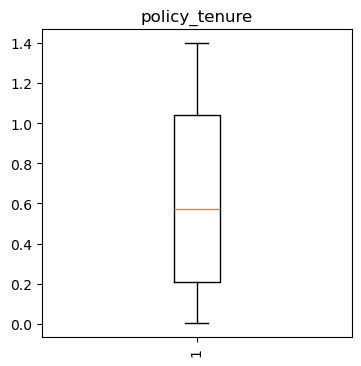

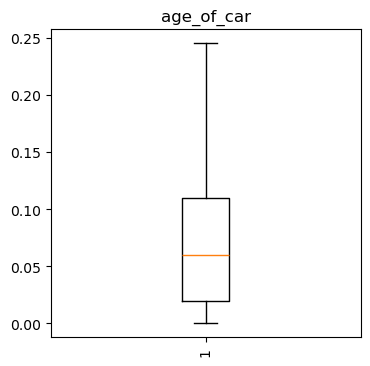

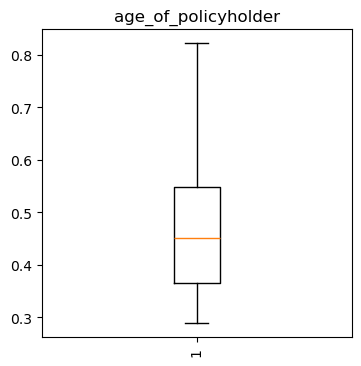

In [37]:
# whole numerical col. visulizing in boxplot
for i in numerical:
   # if df[i].nunique()<1000:
        
       plt.figure(figsize=(4,4))
       plt.title(i) 
       plt.boxplot(x=i, data=df)
       plt.xticks(rotation=90)
plt.show()

#### KDE Plot After Outlier Handling

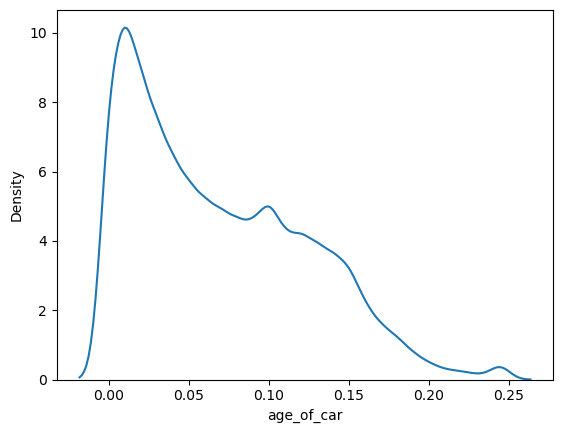

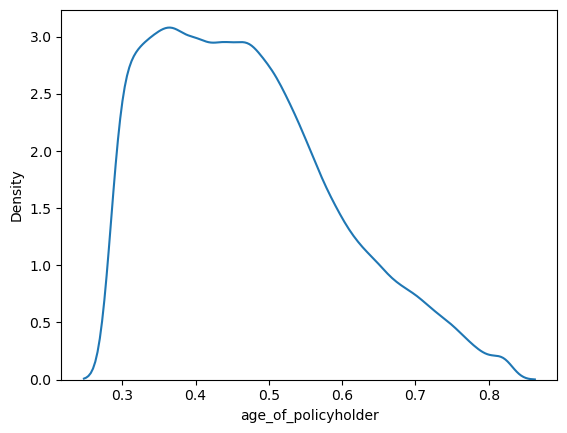

In [38]:
for i in numerical:
    if df[i].nunique() < 1000:
        sns.kdeplot(data=df[i])
        plt.show()    

#### Histogram After Outlier Handling

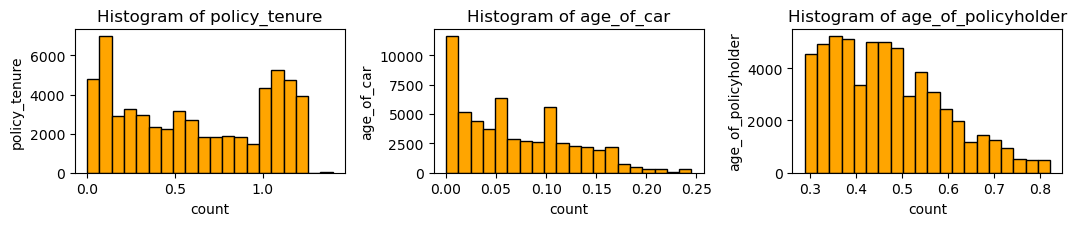

In [39]:
plt.figure(figsize=(18, 10))
for idx, i in enumerate(numerical):
    plt.subplot(5, 5, idx + 1)  # Adjust grid size (5x5) based on number of numerical columns
    plt.hist(df[i], bins=20, color='orange', edgecolor='black')
    plt.title(f'Histogram of {i}')
    plt.xlabel('count')
    plt.ylabel(i)
plt.tight_layout()
plt.show()

In [40]:
df.head()

,policy_id,policy_tenure,age_of_car,age_of_policyholder,area_cluster,population_density,make,segment,model,fuel_type,...,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,is_claim
0,ID00001,0.515874,0.05,0.644231,C1,4990,1,A,M1,CNG,...,No,No,No,Yes,No,No,No,Yes,0,0
1,ID00002,0.672619,0.02,0.375000,C2,27003,1,A,M1,CNG,...,No,No,No,Yes,No,No,No,Yes,0,0
2,ID00003,0.841110,0.02,0.384615,C3,4076,1,A,M1,CNG,...,No,No,No,Yes,No,No,No,Yes,0,0
3,ID00004,0.900277,0.11,0.432692,C4,21622,1,C1,M2,Petrol,...,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,2,0
4,ID00005,0.596403,0.11,0.634615,C5,34738,2,A,M3,Petrol,...,No,Yes,Yes,Yes,No,Yes,Yes,Yes,2,0


In [41]:
df.tail()

,policy_id,policy_tenure,age_of_car,age_of_policyholder,area_cluster,population_density,make,segment,model,fuel_type,...,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,is_claim
58587,ID58588,0.355089,0.13,0.644231,C8,8794,2,A,M3,Petrol,...,No,Yes,Yes,Yes,No,Yes,Yes,Yes,2,0
58588,ID58589,1.199642,0.02,0.519231,C14,7788,1,A,M1,CNG,...,No,No,No,Yes,No,No,No,Yes,0,0
58589,ID58590,1.162273,0.05,0.451923,C5,34738,1,A,M1,CNG,...,No,No,No,Yes,No,No,No,Yes,0,0
58590,ID58591,1.236307,0.14,0.557692,C8,8794,1,B2,M6,Petrol,...,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,2,0
58591,ID58592,0.124429,0.02,0.442308,C8,8794,3,C2,M4,Diesel,...,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,3,0


## 7 X&Y Train Test Split 

In [42]:
x=df.drop(columns=['is_claim'],axis=1)
y=df['is_claim']
categorical.remove('is_claim') # as we are splitting it in x & y

In [43]:
df[numerical].corr()

,policy_tenure,age_of_car,age_of_policyholder
policy_tenure,1.000000,0.168040,0.143546
age_of_car,0.168040,1.000000,-0.038852
age_of_policyholder,0.143546,-0.038852,1.000000


In [44]:
df.shape

(58592, 44)

In [45]:
df['policy_id'].shape

(58592,)

In [46]:
# In policy_id col. all values are unique. Hence we can drop the col.coz polict_id is catg. in nature
df['policy_id'].nunique()

58592

In [47]:
if df['policy_id'].shape[0]==df['policy_id'].nunique():
    x.drop(columns=['policy_id'],axis=1,inplace=True)
    print("'policy_id' dropped from x as all are unique values")
    categorical.remove('policy_id')
else:
    print("'policy_id' NOT dropped from x")

'policy_id' dropped from x as all are unique values


### Label Encoding

In [48]:
from sklearn.preprocessing import LabelEncoder

In [49]:
le=LabelEncoder()

In [50]:
for i in categorical:
    x[i]=le.fit_transform(x[i])

In [51]:
x.head()

,policy_tenure,age_of_car,age_of_policyholder,area_cluster,population_density,make,segment,model,fuel_type,max_torque,...,is_rear_window_defogger,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating
0,0.515874,0.05,0.644231,0,3,0,0,0,0,5,...,0,0,0,0,1,0,0,0,1,0
1,0.672619,0.02,0.375000,11,15,0,0,0,0,5,...,0,0,0,0,1,0,0,0,1,0
2,0.841110,0.02,0.384615,15,2,0,0,0,0,5,...,0,0,0,0,1,0,0,0,1,0
3,0.900277,0.11,0.432692,16,14,0,3,3,2,0,...,1,1,1,1,1,1,1,1,1,1
4,0.596403,0.11,0.634615,17,17,1,0,4,2,8,...,0,0,1,1,1,0,1,1,1,1


In [52]:
# checkin label encoding on categorical col.
for i in categorical:
    print(x[i].unique())
    print("")

[ 0 11 15 16 17 18 19 20 21  1  2  3  4  5  6  7  8  9 10 12 13 14]

[0 3 4 2 1 5]

[ 0  3  4  5  6  7  8  9 10  1  2]

[0 2 1]

[5 0 8 4 3 6 2 7 1]

[2 6 5 0 7 3 8 4 1]

[ 6  2  0  3  4  8  1  9 10  7  5]

[0 1]

[0 1]

[0 1]

[1 0]

[0 1]

[1 0]

[1 0]

[2 0 1]

[0 1]

[0 1]

[0 1]

[0 1]

[0 1]

[0 1]

[0 1]

[1 0]

[0 1]

[0 1]

[0 1]

[1 0]

[ 3 15  2 14 17  9  6  8 12 21  5 18  4  7  0 10 20 19 16 13  1 11]

[0 1 2 3 4]

[1 2 0]

[0 4 2 6 7 1 8 3 5]

[0 1]

[0 1]

[1 3 6 8 4 2 5 0 7]

[0 7 3 8 5 4 1 2 6]

[1 5 2 8 7 6 3 4 0 9]

[ 0  4  1  8  5  6  2  9  3 10  7]

[2 3 1 9 6 5 4 0 7 8]

[0 1 2 4 3]



In [53]:
y.unique()

array([0, 1], dtype=int64)

In [54]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
for i in numerical:
    x[i]=sc.fit_transform(x[[i]])

In [55]:
x.head()

,policy_tenure,age_of_car,age_of_policyholder,area_cluster,population_density,make,segment,model,fuel_type,max_torque,...,is_rear_window_defogger,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating
0,-0.230283,-0.346366,1.428923,0,3,0,0,0,0,5,...,0,0,0,0,1,0,0,0,1,0
1,0.148188,-0.889583,-0.770024,11,15,0,0,0,0,5,...,0,0,0,0,1,0,0,0,1,0
2,0.555022,-0.889583,-0.691490,15,2,0,0,0,0,5,...,0,0,0,0,1,0,0,0,1,0
3,0.697883,0.740067,-0.298821,16,14,0,3,3,2,0,...,1,1,1,1,1,1,1,1,1,1
4,-0.035840,0.740067,1.350389,17,17,1,0,4,2,8,...,0,0,1,1,1,0,1,1,1,1


## 8 Model Building

### 1 LogisticRegression

#### logistic regression before balancing y

In [56]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2,stratify=y)

In [57]:
for i in [x_train,x_test,y_train,y_test]:
    print(i.shape)

(46873, 42)
(11719, 42)
(46873,)
(11719,)


In [58]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()

In [59]:
from sklearn.metrics import accuracy_score,precision_score,recall_score

In [60]:
lr.fit(x_train,y_train)
y_train_predict_lr=lr.predict(x_train)
y_test_predict_lr=lr.predict(x_test)

C:\Users\Welcome\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [61]:
print("train")
print(f"accuracy_score{accuracy_score(y_train,y_train_predict_lr)},precision_score{precision_score(y_train,y_train_predict_lr)},recall_score{recall_score(y_train,y_train_predict_lr)}")

train
accuracy_score0.9360399377040087,precision_score0.0,recall_score0.0


C:\Users\Welcome\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [62]:
print("test")
print(f"accuracy_score{accuracy_score(y_test,y_test_predict_lr)},precision_score{precision_score(y_test,y_test_predict_lr)},recall_score{recall_score(y_test,y_test_predict_lr)}")

test
accuracy_score0.9360013653042069,precision_score0.0,recall_score0.0


C:\Users\Welcome\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


#### Imbalance Treatment Using Oversampling

In [63]:
from imblearn.over_sampling import RandomOverSampler
oversample = RandomOverSampler(sampling_strategy='minority')
x, y = oversample.fit_resample(x, y)

In [64]:
x.shape

(109688, 42)

In [65]:
y.shape

(109688,)

In [66]:
y.value_counts()

is_claim
0    54844
1    54844
Name: count, dtype: int64

In [67]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2,stratify=y)

### logistic regression after Imbalance Treatment Using Oversampling

In [68]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2,stratify=y)
for i in [x_train,x_test,y_train,y_test]:
    print(i.shape)
lr.fit(x_train,y_train)
y_train_predict_lr=lr.predict(x_train)
y_test_predict_lr=lr.predict(x_test)
print("train")
print(f"accuracy_score={accuracy_score(y_train,y_train_predict_lr)},precision_score={precision_score(y_train,y_train_predict_lr)},recall_score={recall_score(y_train,y_train_predict_lr)}")
print("test")
print(f"accuracy_score={accuracy_score(y_test,y_test_predict_lr)},precision_score={precision_score(y_test,y_test_predict_lr)},recall_score={recall_score(y_test,y_test_predict_lr)}")

(87750, 42)
(21938, 42)
(87750,)
(21938,)
train
accuracy_score=0.5755327635327635,precision_score=0.5725386332793416,recall_score=0.5961709401709402
test
accuracy_score=0.5809554198194913,precision_score=0.577963125548727,recall_score=0.6001458656212963


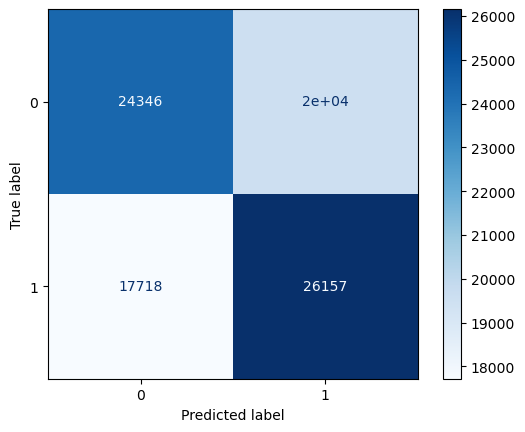

In [69]:
cm = confusion_matrix(y_train,y_train_predict_lr )
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.show()

### 2 Decion Tree Model

recall acc for train :  0.5698175841700162
precision for train :  0.7981082621082621
f1_score for train :  0.6649134133373843
accuracy :  0.5977891737891738


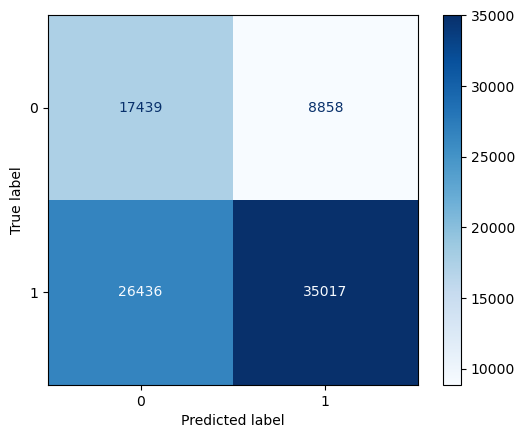

In [70]:
#Decision Tree
DTC =DecisionTreeClassifier(max_depth=2,criterion='entropy')
DTC.fit(x_train,y_train)

y_pred_train = DTC.predict(x_train)
cm = confusion_matrix(y_pred_train,y_train )

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

print("recall acc for train : " , recall_score(y_pred_train,y_train))
print("precision for train : " ,precision_score(y_pred_train,y_train))
print("f1_score for train : " ,f1_score(y_pred_train,y_train))
print("accuracy : " ,accuracy_score(y_pred_train,y_train))
disp.plot(cmap='Blues')

plt.show()

recall acc for test :  0.5713636068342753
precision for test :  0.8018050870635427
f1_score for test :  0.6672483119641909
accuracy :  0.6001458656212963


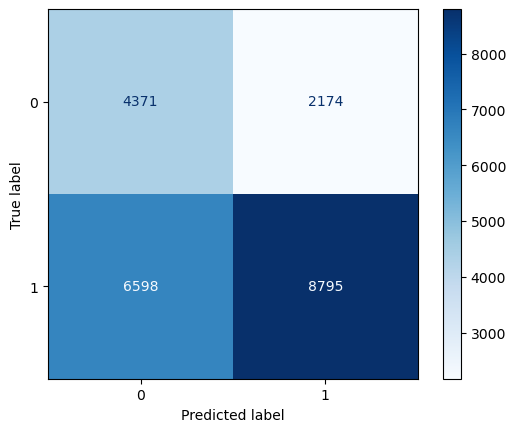

In [71]:
y_pred_test = DTC.predict(x_test)
cm = confusion_matrix(y_pred_test,y_test )

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

print("recall acc for test : " , recall_score(y_pred_test,y_test))
print("precision for test : " ,  precision_score(y_pred_test,y_test))
print("f1_score for test : " ,   f1_score(y_pred_test,y_test))
print("accuracy : " ,accuracy_score(y_pred_test,y_test))

disp.plot(cmap='Blues')

plt.show()

### 3.1 Random Forest Model

In [72]:
from sklearn.ensemble import RandomForestClassifier

In [73]:
for i in range(1,25,5):
    rfc=RandomForestClassifier(n_estimators=i,criterion = 'entropy',max_features=5,random_state=42)
    rfc.fit(x_train,y_train)
    y_train_predict=rfc.predict(x_train)
    y_test_predict=rfc.predict(x_test)
    print("n_estimator =",i)
    print("train")
    print(f"accuracy_score={accuracy_score(y_train,y_train_predict)},precision_score={precision_score(y_train,y_train_predict)},recall_score={recall_score(y_train,y_train_predict)}")
    print("test")
    print(f"accuracy_score={accuracy_score(y_test,y_test_predict)},precision_score={precision_score(y_test,y_test_predict)},recall_score={recall_score(y_test,y_test_predict)}")
    print("")

n_estimator = 1
train
accuracy_score=0.9787578347578347,precision_score=0.9596490076369286,recall_score=0.9995441595441595
test
accuracy_score=0.942109581547999,precision_score=0.896816954422715,recall_score=0.9991795058802079

n_estimator = 6
train
accuracy_score=0.9991225071225072,precision_score=0.9982480888241718,recall_score=1.0
test
accuracy_score=0.9832254535509162,precision_score=0.9675399135573785,recall_score=1.0

n_estimator = 11
train
accuracy_score=0.9992820512820513,precision_score=0.9985661614092585,recall_score=1.0
test
accuracy_score=0.9776643267389917,precision_score=0.9572388515577276,recall_score=1.0

n_estimator = 16
train
accuracy_score=0.9997720797720798,precision_score=0.9995443672400045,recall_score=1.0
test
accuracy_score=0.9829063725043304,precision_score=0.9669428772919605,recall_score=1.0

n_estimator = 21
train
accuracy_score=0.9998062678062678,precision_score=0.9996126856830402,recall_score=1.0
test
accuracy_score=0.9819491293645729,precision_score=0.9651

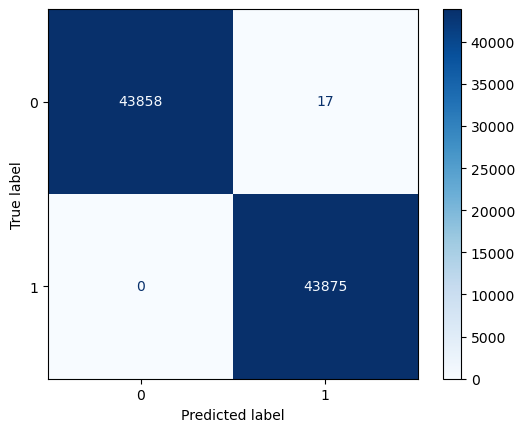

In [74]:
cm = confusion_matrix(y_train,y_train_predict )
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.show()

### 3.2  Finding best parameter for Random Forest using GridSearchCV 

In [75]:
from sklearn.model_selection import GridSearchCV
param_dict={
    'n_estimators':[5,10,15,20,25],
    'max_depth':[3,5,7,9],
    'bootstrap':[True,False],
    'criterion':['gini','entropy'],
    'max_features':['auto', 'log2','sqrt']
}
gscv=GridSearchCV(RandomForestClassifier(),param_grid=param_dict,n_jobs=2,cv=2)
gscv.fit(x_train,y_train)
gscv.best_params_

{'bootstrap': False,
 'criterion': 'gini',
 'max_depth': 9,
 'max_features': 'log2',
 'n_estimators': 25}

In [76]:
param_dict={
    'n_estimators':[30,35,40,45,50],
    'max_depth':[9,11,13,15],
    'bootstrap':[True,False],
    'criterion':['gini','entropy'],
    'max_features':['auto', 'log2','sqrt']
}
gscv=GridSearchCV(RandomForestClassifier(),param_grid=param_dict,n_jobs=2,cv=2)
gscv.fit(x_train,y_train)
gscv.best_params_

{'bootstrap': False,
 'criterion': 'gini',
 'max_depth': 15,
 'max_features': 'sqrt',
 'n_estimators': 45}

### 3.3: Using best parameters on Random Forest

In [77]:
rfc=RandomForestClassifier(bootstrap=False,criterion = 'gini',max_depth=15,max_features='sqrt',n_estimators=40,random_state=42)
rfc.fit(x_train,y_train)
y_train_predict=rfc.predict(x_train)
y_test_predict=rfc.predict(x_test)
print("train")
print(f"accuracy_score={accuracy_score(y_train,y_train_predict)},precision_score={precision_score(y_train,y_train_predict)},recall_score={recall_score(y_train,y_train_predict)}")
print("test")
print(f"accuracy_score={accuracy_score(y_test,y_test_predict)},precision_score={precision_score(y_test,y_test_predict)},recall_score={recall_score(y_test,y_test_predict)}")
print("")

train
accuracy_score=0.8768433048433049,precision_score=0.8130727864879194,recall_score=0.9786894586894587
test
accuracy_score=0.85823684930258,precision_score=0.7899785993653605,recall_score=0.9759321724860972



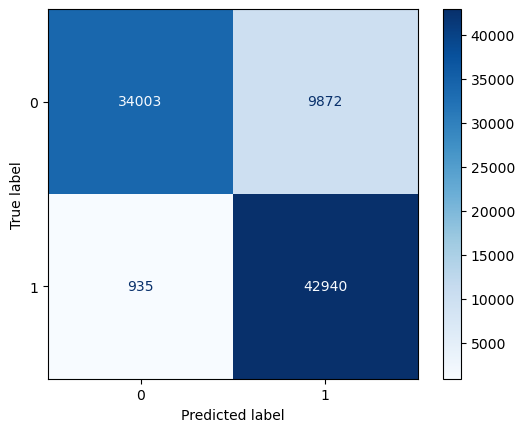

In [78]:
cm = confusion_matrix(y_train,y_train_predict )
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.show()

In [82]:
def calculate_acc(xtrain ,x_test ,y_train ,y_test):
     models =[LogisticRegression(),DecisionTreeClassifier(max_depth=2,criterion='entropy'),RandomForestClassifier(bootstrap=False,criterion = 'gini',max_depth=15,max_features='sqrt',n_estimators=40,random_state=42)]
     data_frame = pd.DataFrame()
     acc =[]
     recall =[]
     precision =[]
     f1=[]
     for mod in models :
         model_ = mod
         model_.fit(x_train ,y_train)
        
         y_pred_test =model_.predict(x_test)
         acc.append(np.round(accuracy_score(y_pred_test,y_test),2))
         recall.append(np.round(recall_score(y_pred_test,y_test),2))  
         precision.append(precision_score(y_pred_test,y_test))
         f1.append(f1_score(y_pred_test,y_test).round(2))
    
    
     tabel =pd.DataFrame(index=["LogisticRegression","DecisionTreeClassifier" ,"RandomForestClassifier"],
                         columns=["acc" ,"recall","precision","F1"] )
     tabel["acc"]    = acc
     tabel["recall"] =recall
     tabel["precision"] = precision 
     tabel["F1"] =f1
     return tabel
print("Accuracy Measurement")
calculate_acc(x_train, x_test, y_train, y_test)

Accuracy Measurement


,acc,recall,precision,F1
LogisticRegression,0.58,0.58,0.600146,0.59
DecisionTreeClassifier,0.60,0.57,0.801805,0.67
RandomForestClassifier,0.86,0.79,0.975932,0.87


In [87]:
tabel=calculate_acc(x_train, x_test, y_train, y_test)

In [88]:
tabel['acc']

LogisticRegression        0.58
DecisionTreeClassifier    0.60
RandomForestClassifier    0.86
Name: acc, dtype: float64

In [89]:
tabel['recall']

LogisticRegression        0.58
DecisionTreeClassifier    0.57
RandomForestClassifier    0.79
Name: recall, dtype: float64

In [90]:
tabel['precision']

LogisticRegression        0.600146
DecisionTreeClassifier    0.801805
RandomForestClassifier    0.975932
Name: precision, dtype: float64

In [92]:
tabel['F1']

LogisticRegression        0.59
DecisionTreeClassifier    0.67
RandomForestClassifier    0.87
Name: F1, dtype: float64

In [95]:
tabel.index

Index(['LogisticRegression', 'DecisionTreeClassifier',
       'RandomForestClassifier'],
      dtype='object')

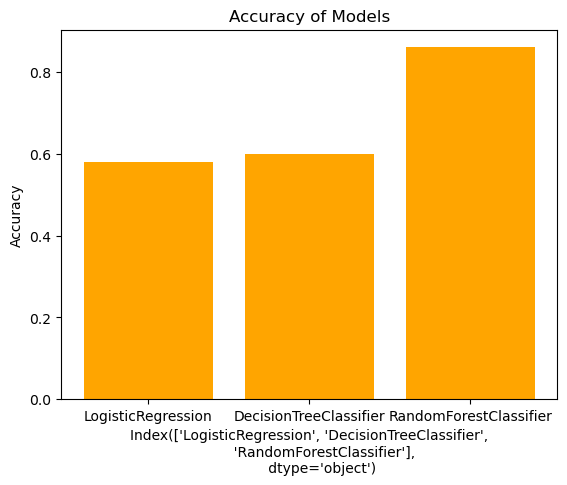

<Figure size 640x480 with 0 Axes>

In [101]:
plt.bar(tabel.index, tabel['acc'], color='orange')
plt.title('Accuracy of Models')
plt.xlabel(tabel.index)
plt.ylabel('Accuracy')
plt.figure()
plt.show()

## END